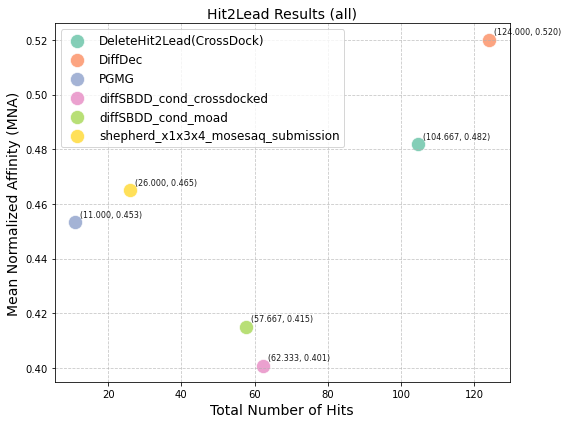

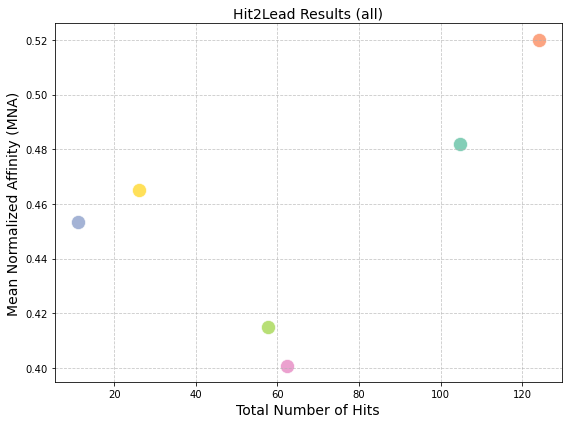

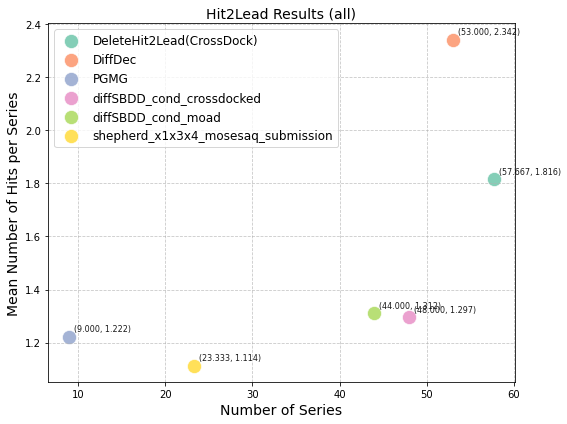

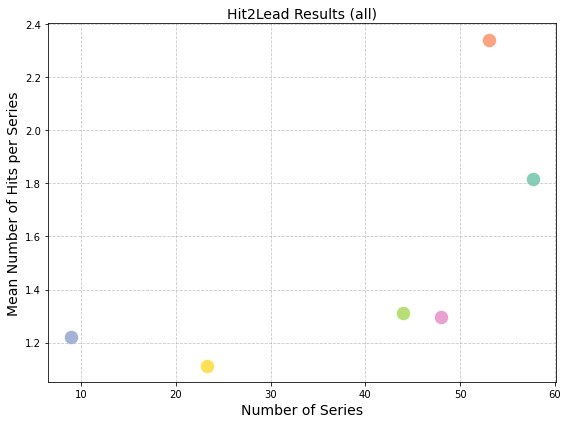

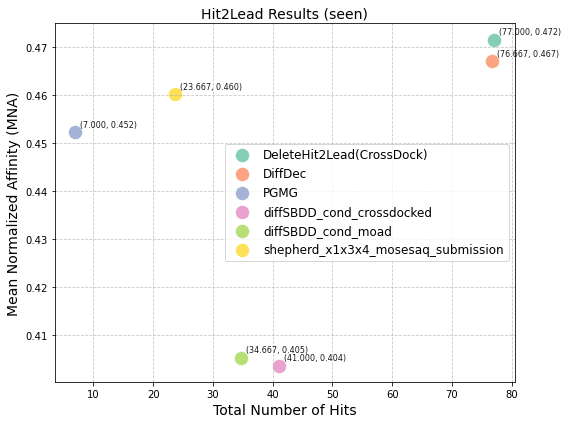

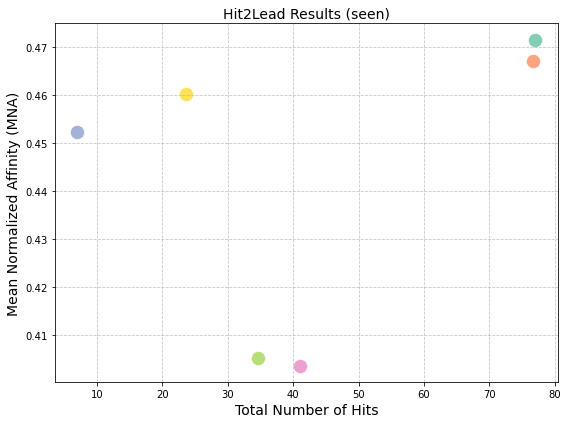

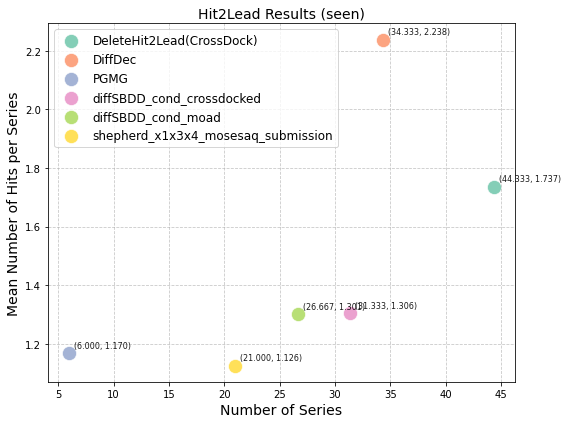

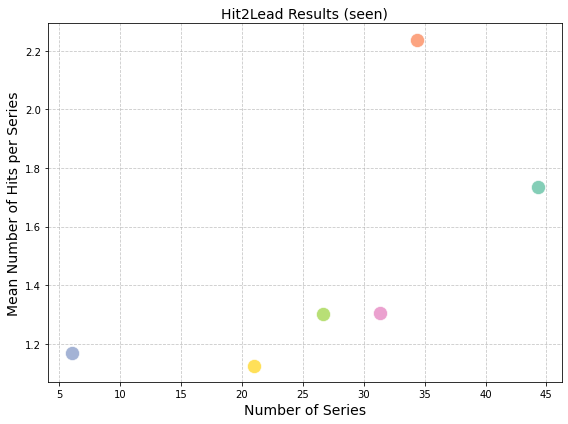

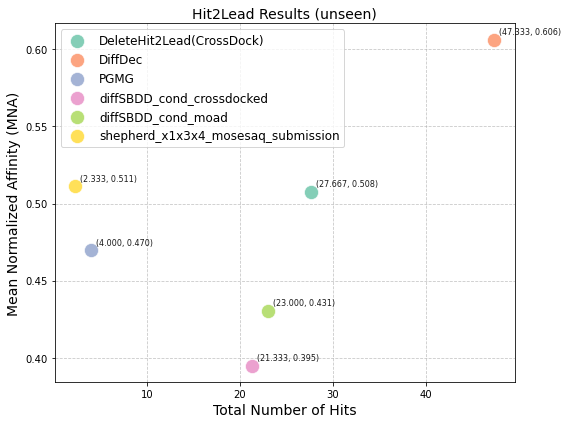

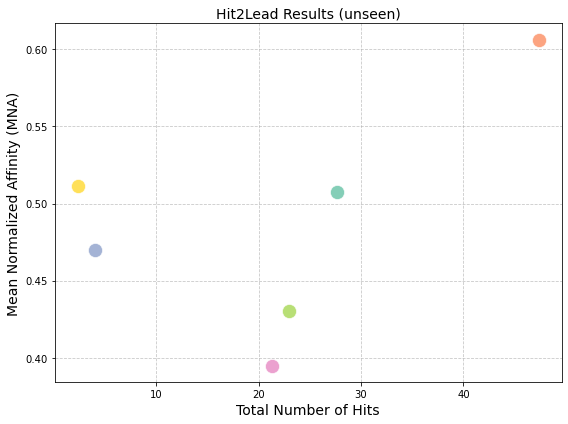

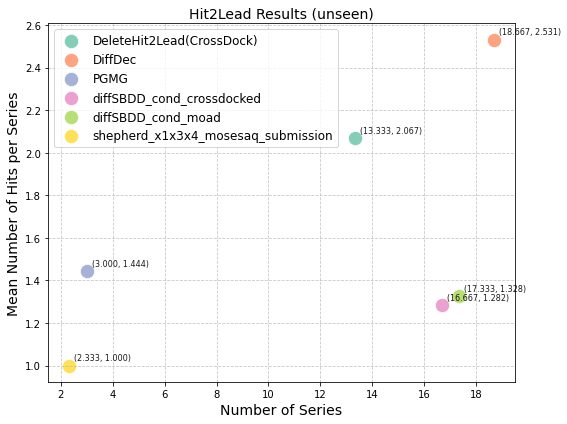

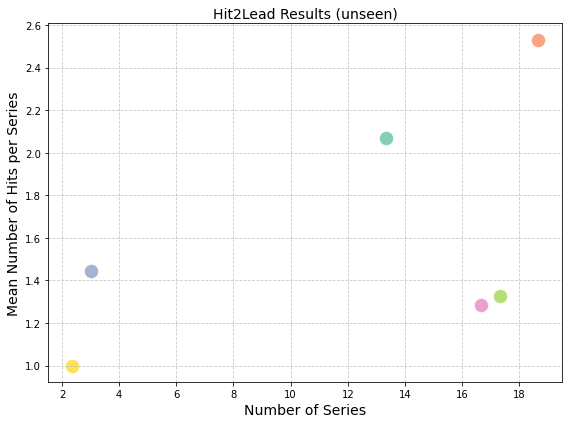

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt


# ========== 数据读取配置 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_dir = "/home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow/final_plot/output/h2l_affinity"
os.makedirs(save_dir, exist_ok=True)

round_list = ["Round1", "Round2", "Round3"]

# ========== Hit2Lead 配置 ==========
TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    # "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "diffSBDD_cond_crossdocked",
    "diffSBDD_cond_moad_Hit_to_Lead": "diffSBDD_cond_moad",
    # "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "shepherd_x1x3x4_mosesaq_submission",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "DeleteHit2Lead(CrossDock)",
    "PGMG_Hit_to_Lead": "PGMG",
}


# ========== 从 YAML 读取 Hit2Lead 数据 ==========
def load_hit2lead_data_from_yaml(data_path, round_list, task_list, name_mapping):
    """
    从 YAML 文件读取 Hit2Lead 数据
    """
    results_all = []
    results_seen = []
    results_unseen = []

    for round_name in round_list:
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, "Hit_to_Lead_Results", task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)
                
                # 处理除零情况
                def safe_divide(a, b):
                    return a / b if b > 0 else 0
                
                # All proteins
                all_data = result['metrics']['HitRediscover']['all']
                results_all.append({
                    "ModelName": name_mapping[task],
                    "Round": round_name,
                    "Serise_Num": all_data['smiles_hit_recovery'],
                    "NumberHits_sum": all_data['smiles_hit_num'],
                    "Finded_Smiles_Affinity_mean": all_data['Mean_normalized_affinity'],
                    "NumberHits_Mean": safe_divide(all_data['smiles_hit_num'], all_data['smiles_hit_recovery']),
                })
                
                # Seen proteins
                seen_data = result['metrics']['HitRediscover']['seen']
                results_seen.append({
                    "ModelName": name_mapping[task],
                    "Round": round_name,
                    "Serise_Num": seen_data['smiles_hit_recovery'],
                    "NumberHits_sum": seen_data['smiles_hit_num'],
                    "Finded_Smiles_Affinity_mean": seen_data['Mean_normalized_affinity'],
                    "NumberHits_Mean": safe_divide(seen_data['smiles_hit_num'], seen_data['smiles_hit_recovery']),
                })
                
                # Unseen proteins
                unseen_data = result['metrics']['HitRediscover']['unseen']
                results_unseen.append({
                    "ModelName": name_mapping[task],
                    "Round": round_name,
                    "Serise_Num": unseen_data['smiles_hit_recovery'],
                    "NumberHits_sum": unseen_data['smiles_hit_num'],
                    "Finded_Smiles_Affinity_mean": unseen_data['Mean_normalized_affinity'],
                    "NumberHits_Mean": safe_divide(unseen_data['smiles_hit_num'], unseen_data['smiles_hit_recovery']),
                })

    return {
        'all': pd.DataFrame(results_all),
        'seen': pd.DataFrame(results_seen),
        'unseen': pd.DataFrame(results_unseen)
    }


# ========== 聚合数据函数 ==========
def get_aggregated_data(df):
    """
    按 ModelName 聚合数据，计算 mean 和 std
    """
    agg_cols = ['Serise_Num', 'NumberHits_sum', 'Finded_Smiles_Affinity_mean', 'NumberHits_Mean']
    data = df.groupby('ModelName')[agg_cols].agg(['mean', 'std']).reset_index()
    data.columns = ['ModelName'] + [f'{col}_{stat}' for col in agg_cols for stat in ['mean', 'std']]
    return data


# ========== 绘图函数 ==========
def plot_scatter(data, x_feature, y_feature, type_name, save_dir, legend=True, show_coords=True):
    """
    绘制散点图
    """
    plt.figure(figsize=(8, 6))
    
    # 创建颜色映射
    color_list = sns.color_palette("Set2", n_colors=len(data))
    model_names = sorted(data['ModelName'].unique())
    color_map = {name: color_list[i % len(color_list)] for i, name in enumerate(model_names)}
    
    # 为每个模型绘制散点
    for model in model_names:
        model_data = data[data['ModelName'] == model]
        x_val = model_data[f'{x_feature}_mean'].values[0]
        y_val = model_data[f'{y_feature}_mean'].values[0]
        
        plt.scatter(
            x=x_val,
            y=y_val,
            color=color_map[model],
            marker='o',
            s=200,
            alpha=0.8,
            edgecolor="w",
            linewidth=0.8,
            label=model
        )
        
        # 显示坐标标注
        if show_coords:
            plt.annotate(
                f'({x_val:.3f}, {y_val:.3f})',
                xy=(x_val, y_val),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                alpha=0.9
            )
    
    # 设置标签
    x_label_map = {
        'Serise_Num': 'Number of Series',
        'NumberHits_sum': 'Total Number of Hits'
    }
    y_label_map = {
        'Finded_Smiles_Affinity_mean': 'Mean Normalized Affinity (MNA)',
        'NumberHits_Mean': 'Mean Number of Hits per Series'
    }
    
    plt.xlabel(x_label_map.get(x_feature, x_feature), fontsize=14)
    plt.ylabel(y_label_map.get(y_feature, y_feature), fontsize=14)
    plt.title(f'Hit2Lead Results ({type_name})', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if legend:
        plt.legend(fontsize=12, loc='best')
        suffix = '_legend'
    else:
        suffix = ''
    
    if show_coords:
        suffix += '_coords'
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, f'hit2lead_{type_name}_{y_feature}{suffix}.svg')
    plt.savefig(save_path, bbox_inches='tight', dpi=600, format='svg')
    # print(f'Saved: {save_path}')
    plt.show()
    plt.close()



# ========== 主程序 ==========
# 读取数据
data_dict = load_hit2lead_data_from_yaml(data_path, round_list, TASK_LIST_H2L, H2L_NAME_MAPPING)

# 定义特征组合 (修正配对关系)
# MNA 配 Number of Hits, Mean Number of Hits 配 Number of Series
feature_pairs = [
    ('NumberHits_sum', 'Finded_Smiles_Affinity_mean'),      # x: Number of Hits, y: MNA
    ('Serise_Num', 'NumberHits_Mean'),                       # x: Number of Series, y: Mean Number of Hits
]

# 遍历所有组合
for type_name in ['all', 'seen', 'unseen']:
    agg_data = get_aggregated_data(data_dict[type_name])
    
    for x_feature, y_feature in feature_pairs:
        # 带 legend 和坐标
        plot_scatter(agg_data, x_feature, y_feature, type_name, save_dir, legend=True, show_coords=True)
        # 不带坐标
        plot_scatter(agg_data, x_feature, y_feature, type_name, save_dir, legend=False, show_coords=False)

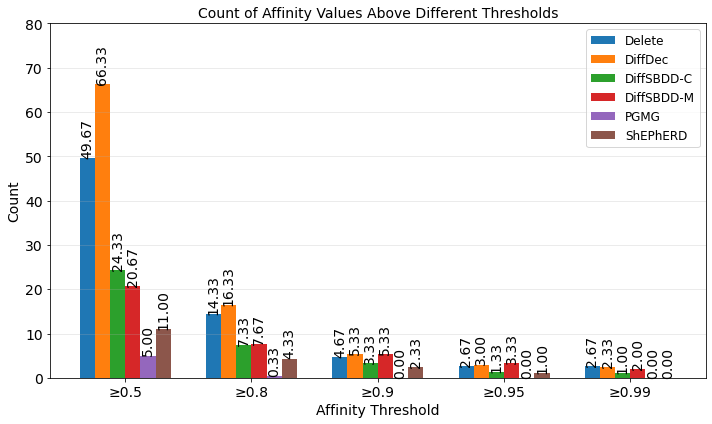

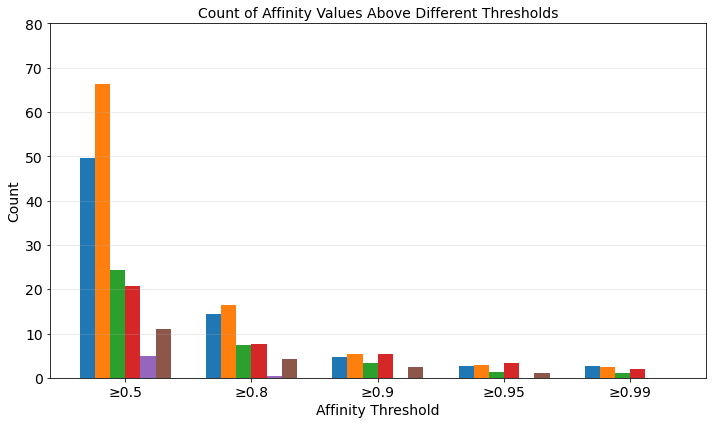

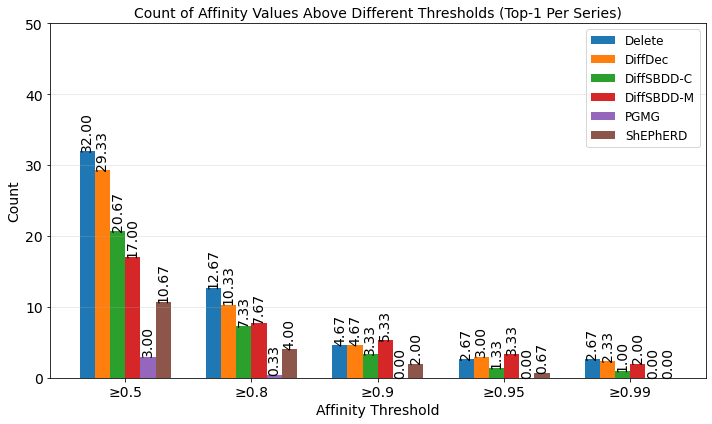

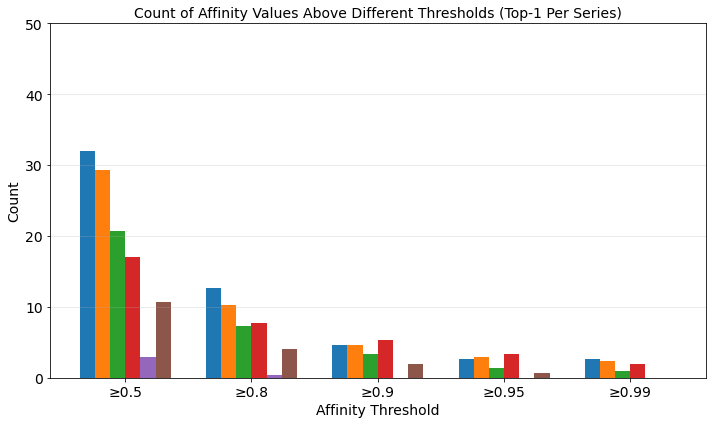

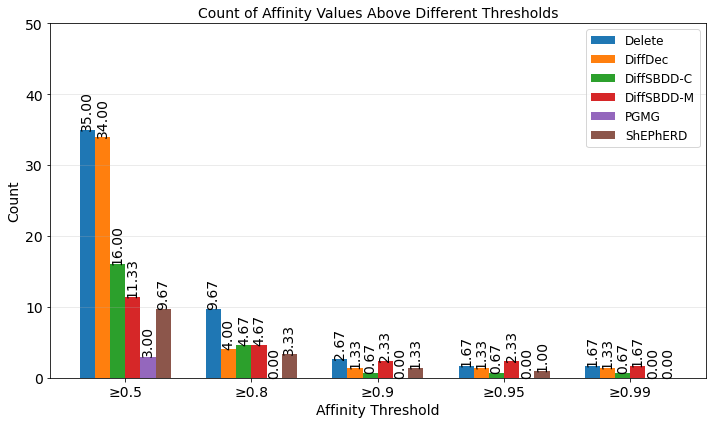

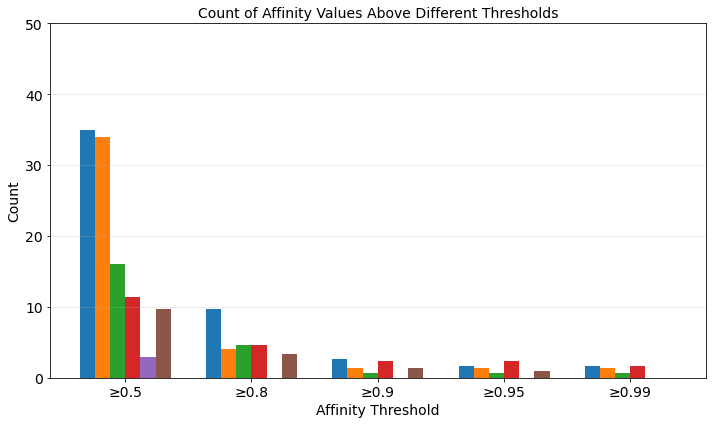

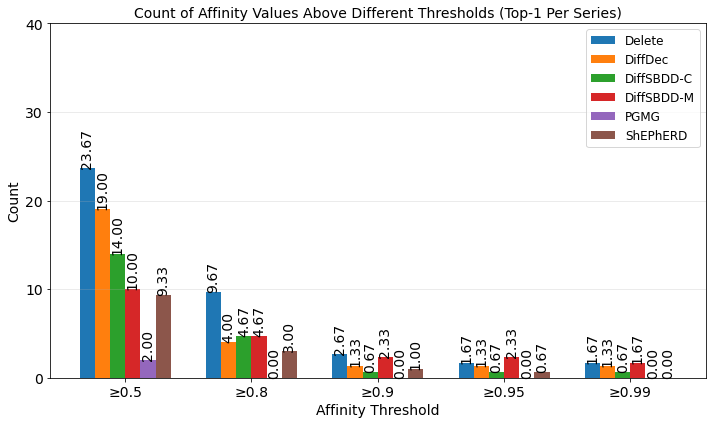

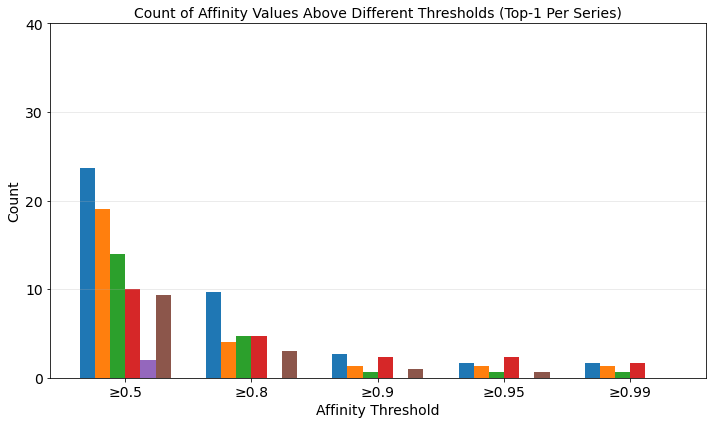

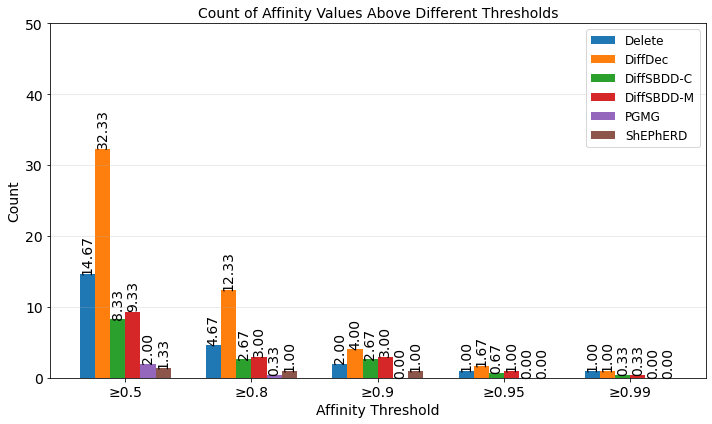

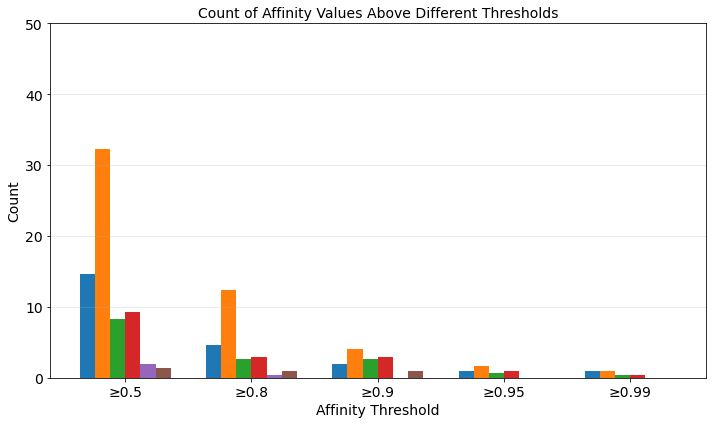

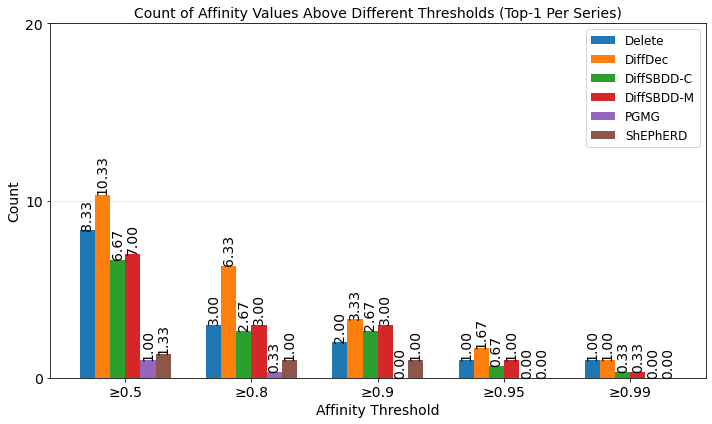

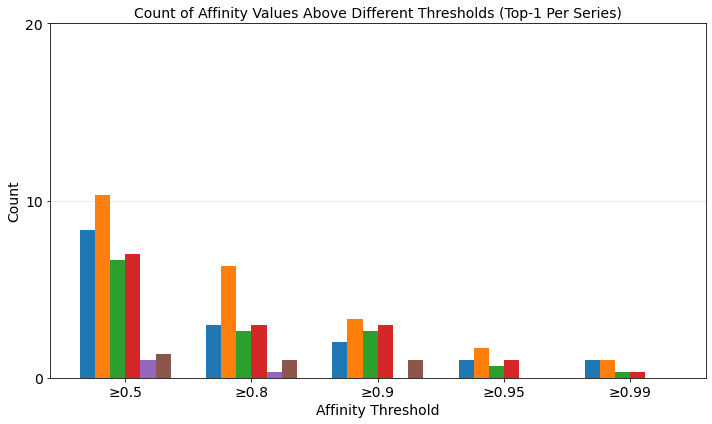

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

# ========== 数据读取配置 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_dir = "/home/user-home/fanzhehuan/myprojects/MolGenBench/FigShow/final_plot/output/h2l_affinity_bar"
os.makedirs(save_dir, exist_ok=True)

round_list = ["Round1", "Round2", "Round3"]

# ========== Hit2Lead 配置 ==========
TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    "PGMG_Hit_to_Lead": "PGMG",
}

# ========== 从 YAML 读取 Hit2Lead 数据 ==========
def load_hit2lead_data_from_yaml(data_path, round_list, task_list, name_mapping):
    results_all = []
    results_seen = []
    results_unseen = []

    for round_name in round_list:
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, "Hit_to_Lead_Results", task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)
                
                for protein_type, results_list in [('all', results_all), ('seen', results_seen), ('unseen', results_unseen)]:
                    data = result['metrics']['HitRediscover'][protein_type]
                    results_list.append({
                        "ModelName": name_mapping[task],
                        "Round": round_name,
                        **{f"sum_normalized_affinity_count_>=_{t}": data[f"sum_normalized_affinity_count_>=_{t}"] for t in [0.5, 0.8, 0.9, 0.95, 0.99]},
                        **{f"sum_max_normalized_affinity_count_>=_{t}": data[f"sum_max_normalized_affinity_count_>=_{t}"] for t in [0.5, 0.8, 0.9, 0.95, 0.99]},
                    })

    return {
        'all': pd.DataFrame(results_all),
        'seen': pd.DataFrame(results_seen),
        'unseen': pd.DataFrame(results_unseen)
    }


# ========== 转换为绘图格式 ==========
def convert_to_plot_format(df, col_prefix='sum_normalized_affinity_count'):
    """
    将聚合数据转换为 plot_count_bar 需要的格式
    col_prefix: 'sum_normalized_affinity_count' 或 'sum_max_normalized_affinity_count'
    """
    thresholds = [0.5, 0.8, 0.9, 0.95, 0.99]
    
    # 按 ModelName 聚合三个 Round 的平均值
    agg_cols = [f"{col_prefix}_>=_{t}" for t in thresholds]
    agg_data = df.groupby('ModelName')[agg_cols].mean().reset_index()
    
    # 重命名列以匹配绘图函数
    rename_map = {f"{col_prefix}_>=_{t}": f">={t}" for t in thresholds}
    agg_data = agg_data.rename(columns=rename_map)
    agg_data = agg_data.rename(columns={'ModelName': 'Model'})
    agg_data = agg_data.set_index('Model')
    
    return agg_data


# ========== 绘图函数 ==========
def plot_count_bar(count_data, title_name='Count of Affinity Values Above Different Thresholds by Model', 
                   protein_type='all', show_legend=True, show_values=True):
    plt.figure(figsize=(10, 6))
    
    thresholds = [0.5, 0.8, 0.9, 0.95, 0.99]
    x = np.arange(len(thresholds))
    width = 0.12
    
    models = count_data.index.tolist()
    count_columns = [f'>={t}' for t in thresholds]
    margin = 0.1
    
    # colors = sns.color_palette("Set2", n_colors=len(models))
    
    for i, model in enumerate(models):
        model_counts = [count_data.loc[model, col] for col in count_columns]
        bars = plt.bar(x + margin + i * width, model_counts, width, label=model)
        
        if show_values:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=14, rotation=90)

    plt.xlabel('Affinity Threshold', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.title(title_name, fontsize=14)
    plt.xticks(x + margin + width * (len(models)-1)/2, [f'≥{t}' for t in thresholds], fontsize=14)
    
    y_max = count_data.max().max()
    plt.yticks(np.arange(0, int(y_max) + 20, 10), fontsize=14)
    
    if show_legend:
        plt.legend(loc='upper right', fontsize=12)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    
    suffix = ''
    if show_legend:
        suffix += '_legend'
    if show_values:
        suffix += '_values'
    
    plt.savefig(f'{save_dir}/{title_name}_{protein_type}{suffix}.svg', bbox_inches='tight', dpi=600, format='svg')
    plt.show()
    plt.close()


# ========== 主程序 ==========
# 读取数据
data_dict = load_hit2lead_data_from_yaml(data_path, round_list, TASK_LIST_H2L, H2L_NAME_MAPPING)

# 遍历所有组合绘图
for protein_type in ['all', 'seen', 'unseen']:
    df = data_dict[protein_type]
    
    # 所有 SMILES 的 affinity count
    count_data = convert_to_plot_format(df, col_prefix='sum_normalized_affinity_count')
    plot_count_bar(count_data, 
                   title_name='Count of Affinity Values Above Different Thresholds',
                   protein_type=protein_type, show_legend=True, show_values=True)
    plot_count_bar(count_data, 
                   title_name='Count of Affinity Values Above Different Thresholds',
                   protein_type=protein_type, show_legend=False, show_values=False)
    
    # Top-1 Affinity Per Series
    count_data_max = convert_to_plot_format(df, col_prefix='sum_max_normalized_affinity_count')
    plot_count_bar(count_data_max, 
                   title_name='Count of Affinity Values Above Different Thresholds (Top-1 Per Series)',
                   protein_type=protein_type, show_legend=True, show_values=True)
    plot_count_bar(count_data_max, 
                   title_name='Count of Affinity Values Above Different Thresholds (Top-1 Per Series)',
                   protein_type=protein_type, show_legend=False, show_values=False)